# 🩺 Diabetes Prediction v2 – Early Symptom Dataset
**Teknik improvement:** SMOTE + Class Weight Balancing + Threshold Tuning + GridSearchCV

> **Fokus utama:** Recall ≥ 85% agar penderita diabetes tidak salah didiagnosis sebagai sehat
>
> **Dataset:** Early-stage diabetes risk prediction (UCI) — 520 sampel, 16 fitur gejala klinis

---

## 📦 Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print('✅ Library berhasil di-import')

✅ Library berhasil di-import


In [2]:
# --- Environment & Library Versions (Reproducibility) ---
import sklearn, imblearn
print(f'Python          : {__import__("sys").version.split()[0]}')
print(f'pandas          : {pd.__version__}')
print(f'numpy           : {np.__version__}')
print(f'scikit-learn    : {sklearn.__version__}')
print(f'imbalanced-learn: {imblearn.__version__}')
print(f'matplotlib      : {__import__("matplotlib").__version__}')
print('\n✅ Library & versi tercatat untuk reproducibility')

Python          : 3.13.5
pandas          : 2.2.3
numpy           : 2.1.3
scikit-learn    : 1.6.1
imbalanced-learn: 0.13.0
matplotlib      : 3.10.0

✅ Library & versi tercatat untuk reproducibility


---
## 1️⃣ Load Dataset

In [3]:
# Dataset ini menggunakan separator titik koma (;)
df = pd.read_csv('diabetes_data.csv', sep=';')

print(f'Total data  : {df.shape[0]} baris, {df.shape[1]} kolom')
print(f'Fitur       : {df.shape[1] - 1} (termasuk age & gender)')
print(f'Target      : class (1 = Diabetes Positif, 0 = Negatif)')
df.head()

Total data  : 520 baris, 17 kolom
Fitur       : 16 (termasuk age & gender)
Target      : class (1 = Diabetes Positif, 0 = Negatif)


,age,gender,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity,class
0,40,Male,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,Male,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,Male,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,Male,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,Male,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


In [4]:
# --- 1.1 Informasi Dataset ---
print('=== INFO DATASET ===')
df.info()
print('\n=== CEK MISSING VALUE ===')
print(df.isnull().sum().to_string())
print(f'\nTotal missing value: {df.isnull().sum().sum()}')
print('\n=== STATISTIK DESKRIPTIF ===')
df.describe()

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   age                 520 non-null    int64 
 1   gender              520 non-null    object
 2   polyuria            520 non-null    int64 
 3   polydipsia          520 non-null    int64 
 4   sudden_weight_loss  520 non-null    int64 
 5   weakness            520 non-null    int64 
 6   polyphagia          520 non-null    int64 
 7   genital_thrush      520 non-null    int64 
 8   visual_blurring     520 non-null    int64 
 9   itching             520 non-null    int64 
 10  irritability        520 non-null    int64 
 11  delayed_healing     520 non-null    int64 
 12  partial_paresis     520 non-null    int64 
 13  muscle_stiffness    520 non-null    int64 
 14  alopecia            520 non-null    int64 
 15  obesity             520 non-null    int64 
 16  class

,age,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity,class
count,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000,520.000000
mean,48.028846,0.496154,0.448077,0.417308,0.586538,0.455769,0.223077,0.448077,0.486538,0.242308,0.459615,0.430769,0.375000,0.344231,0.169231,0.615385
std,12.151466,0.500467,0.497776,0.493589,0.492928,0.498519,0.416710,0.497776,0.500300,0.428892,0.498846,0.495661,0.484589,0.475574,0.375317,0.486973
min,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,47.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,57.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
max,90.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
# --- 1.2 Cek Nilai Unik Kolom Kategorik ---
print('Nilai unik gender:', df['gender'].unique())
print('Nilai unik class :', df['class'].unique())
print('\nDistribusi class:')
print(df['class'].value_counts())
print(f'\nRasio kelas: {df["class"].value_counts()[0]}:{df["class"].value_counts()[1]}')

Nilai unik gender: ['Male' 'Female']
Nilai unik class : [1 0]

Distribusi class:
class
1    320
0    200
Name: count, dtype: int64

Rasio kelas: 200:320


---
## 2️⃣ Exploratory Data Analysis (EDA)

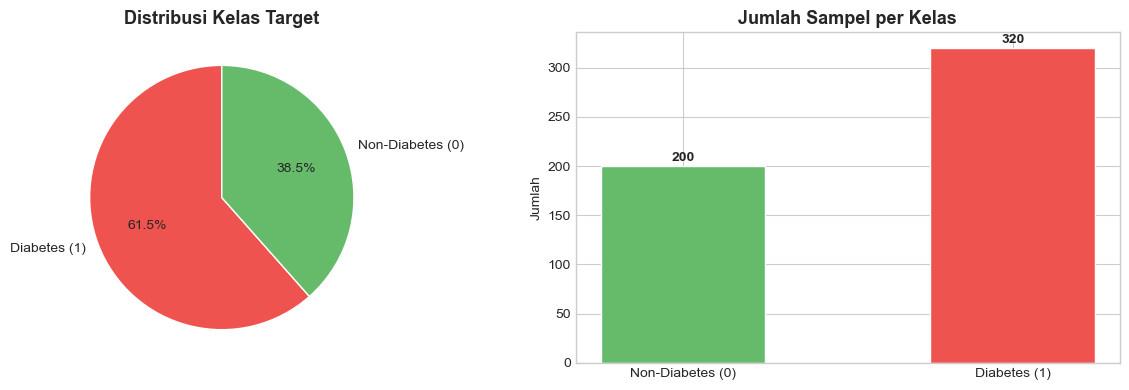

Rasio kelas: 200:320 → Dataset imbalanced, perlu SMOTE!


In [6]:
# --- 2.1 Distribusi Kelas Target ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df['class'].value_counts()
axes[0].pie(counts, labels=['Diabetes (1)', 'Non-Diabetes (0)'],
            autopct='%1.1f%%', colors=['#ef5350', '#66bb6a'],
            startangle=90, wedgeprops=dict(edgecolor='white'))
axes[0].set_title('Distribusi Kelas Target', fontsize=13, fontweight='bold')
axes[1].bar(['Non-Diabetes (0)', 'Diabetes (1)'],
            [counts.get(0, 0), counts.get(1, 0)],
            color=['#66bb6a', '#ef5350'], edgecolor='white', width=0.5)
for i, v in enumerate([counts.get(0, 0), counts.get(1, 0)]):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[1].set_title('Jumlah Sampel per Kelas', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Jumlah')
plt.tight_layout()
plt.show()
print(f'Rasio kelas: {counts.get(0,0)}:{counts.get(1,0)} → Dataset imbalanced, perlu SMOTE!')

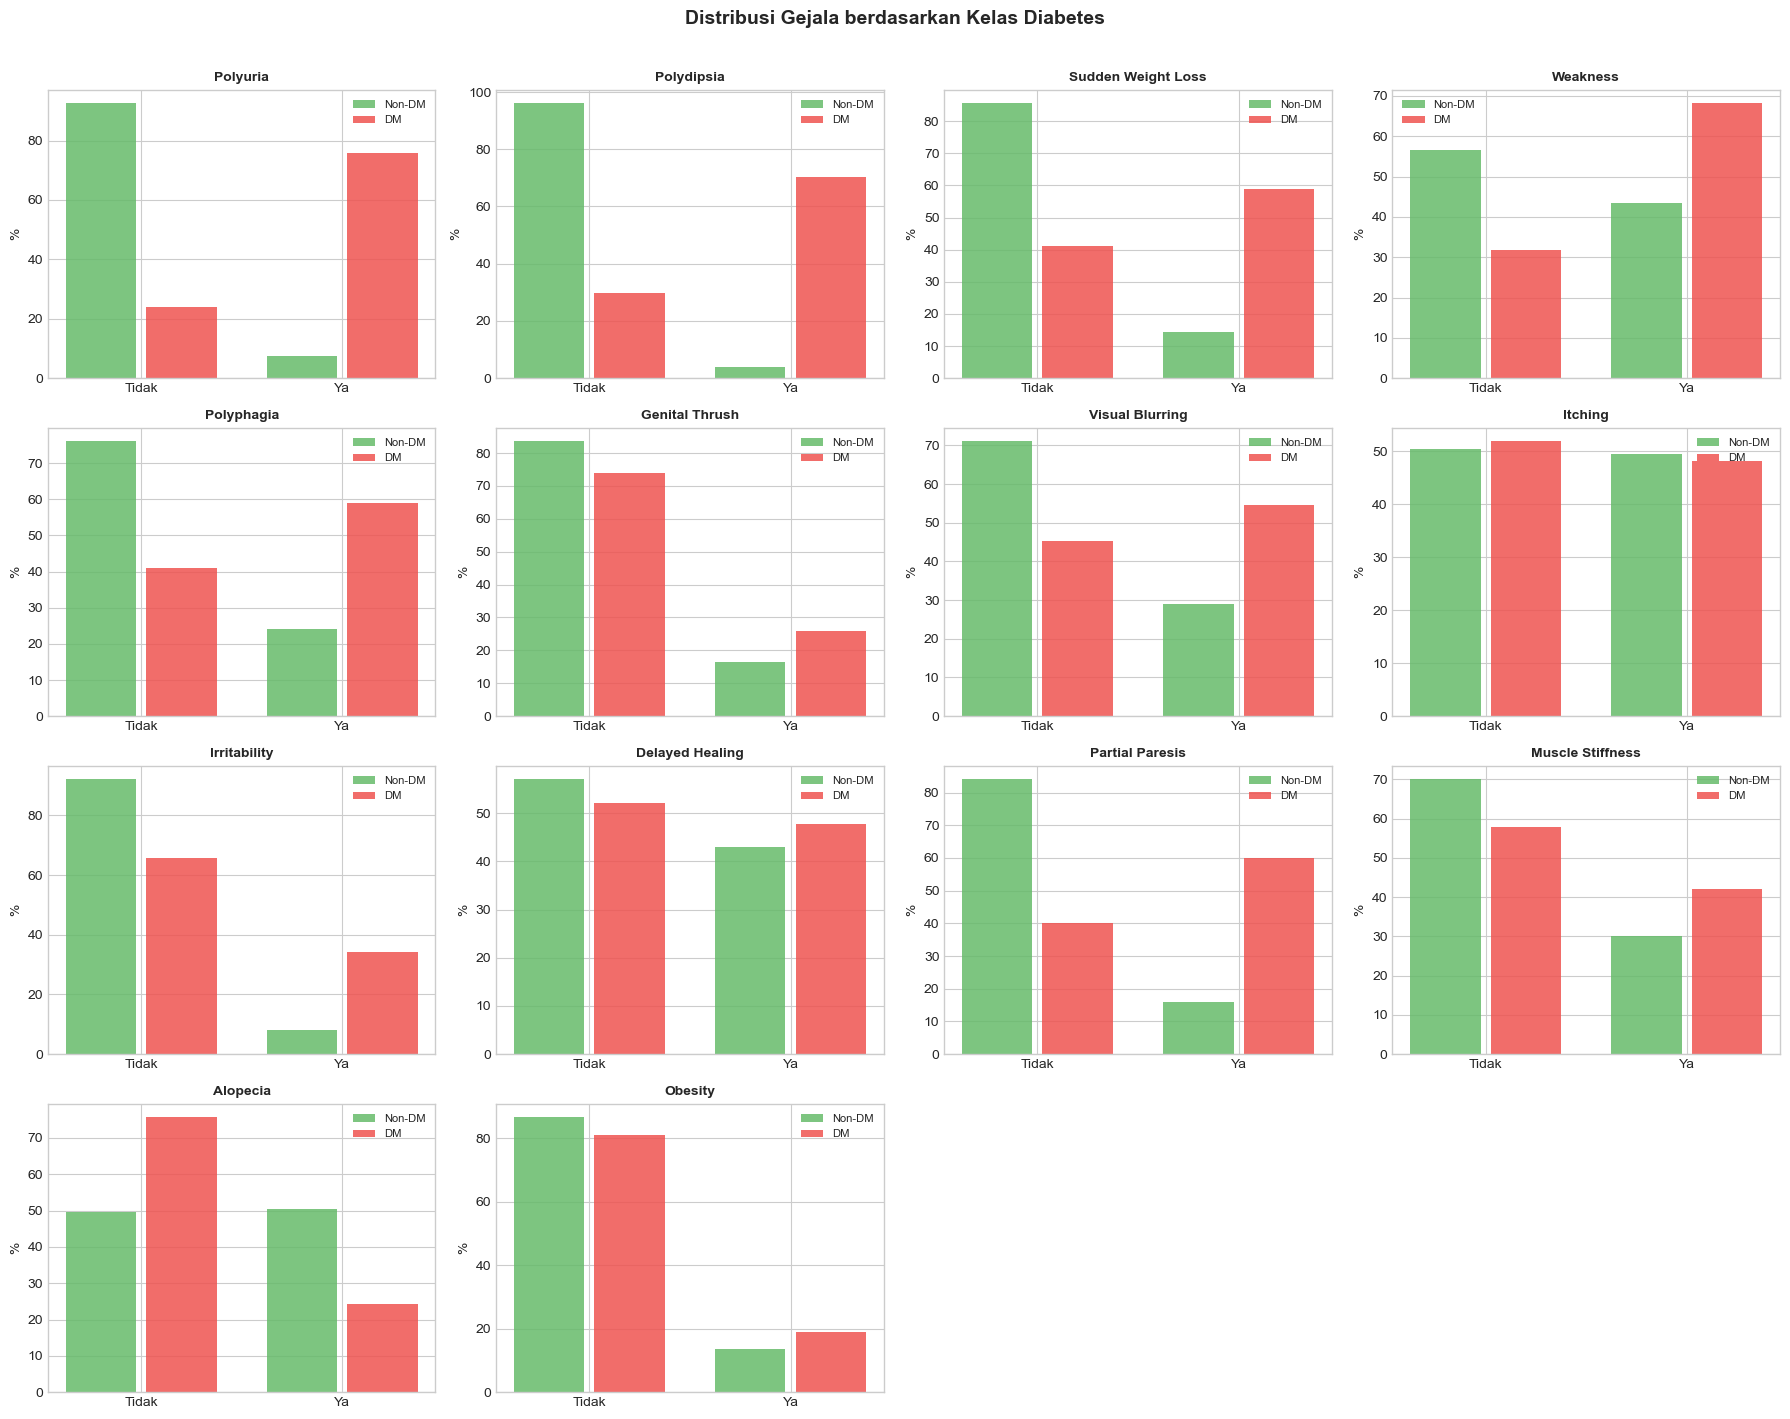

In [7]:
# --- 2.2 Distribusi Fitur Binary (Symptom) per Kelas ---
symptom_cols = [
    'polyuria', 'polydipsia', 'sudden_weight_loss', 'weakness',
    'polyphagia', 'genital_thrush', 'visual_blurring', 'itching',
    'irritability', 'delayed_healing', 'partial_paresis',
    'muscle_stiffness', 'alopecia', 'obesity'
]

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()
colors = {'0': '#66bb6a', '1': '#ef5350'}

for i, col in enumerate(symptom_cols):
    dm0 = df[df['class'] == 0][col].value_counts(normalize=True) * 100
    dm1 = df[df['class'] == 1][col].value_counts(normalize=True) * 100
    x = np.arange(2)
    axes[i].bar(x - 0.2, [dm0.get(0, 0), dm0.get(1, 0)], 0.35,
                color='#66bb6a', label='Non-DM', alpha=0.85)
    axes[i].bar(x + 0.2, [dm1.get(0, 0), dm1.get(1, 0)], 0.35,
                color='#ef5350', label='DM', alpha=0.85)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Tidak', 'Ya'])
    axes[i].set_ylabel('%')
    axes[i].legend(fontsize=8)

# Sembunyikan subplot kosong
for j in range(len(symptom_cols), len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribusi Gejala berdasarkan Kelas Diabetes', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

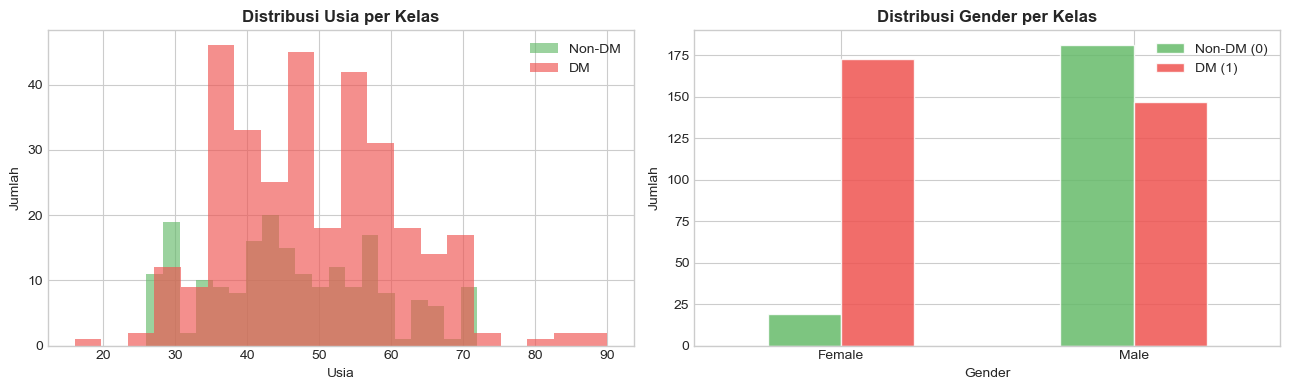

In [8]:
# --- 2.3 Distribusi Usia & Gender ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df[df['class'] == 0]['age'], bins=20, alpha=0.65, color='#66bb6a', label='Non-DM')
axes[0].hist(df[df['class'] == 1]['age'], bins=20, alpha=0.65, color='#ef5350', label='DM')
axes[0].set_title('Distribusi Usia per Kelas', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Usia')
axes[0].set_ylabel('Jumlah')
axes[0].legend()

gender_class = df.groupby(['gender', 'class']).size().unstack(fill_value=0)
gender_class.plot(kind='bar', ax=axes[1], color=['#66bb6a', '#ef5350'],
                  edgecolor='white', alpha=0.85, width=0.5)
axes[1].set_title('Distribusi Gender per Kelas', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Jumlah')
axes[1].legend(['Non-DM (0)', 'DM (1)'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

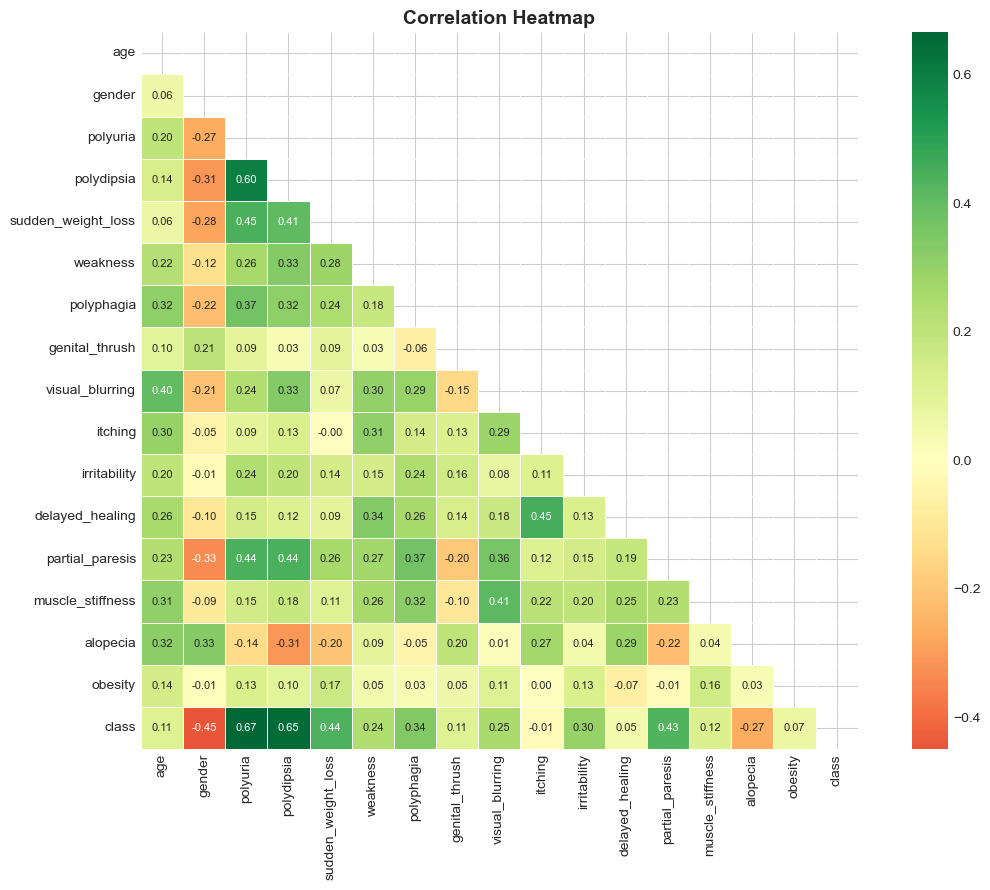

Korelasi dengan class (target):
polyuria              0.665922
polydipsia            0.648734
sudden_weight_loss    0.436568
partial_paresis       0.432288
polyphagia            0.342504
irritability          0.299467
visual_blurring       0.251300
weakness              0.243275
muscle_stiffness      0.122474
genital_thrush        0.110288
age                   0.108679
obesity               0.072173
delayed_healing       0.046980
itching              -0.013384
alopecia             -0.267512
gender               -0.449233


In [9]:
# --- 2.4 Heatmap Korelasi (setelah encoding) ---
df_corr = df.copy()
df_corr['gender'] = LabelEncoder().fit_transform(df_corr['gender'])  # Male=1, Female=0

plt.figure(figsize=(12, 9))
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5, square=True,
            annot_kws={'size': 8})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Korelasi dengan class (target):')
print(corr['class'].drop('class').sort_values(ascending=False).to_string())

---
## 3️⃣ Data Preparation

In [10]:
# --- 3.1 Encoding Kolom Kategorik ---
# gender: Male → 1, Female → 0
df_clean = df.copy()
le = LabelEncoder()
df_clean['gender'] = le.fit_transform(df_clean['gender'])
print('Mapping gender:', dict(zip(le.classes_, le.transform(le.classes_))))
print('\n✅ Encoding selesai')
df_clean.head(3)

Mapping gender: {'Female': np.int64(0), 'Male': np.int64(1)}

✅ Encoding selesai


,age,gender,polyuria,polydipsia,sudden_weight_loss,weakness,polyphagia,genital_thrush,visual_blurring,itching,irritability,delayed_healing,partial_paresis,muscle_stiffness,alopecia,obesity,class
0,40,1,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,1,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1


In [11]:
# --- 3.2 Split Fitur dan Target ---
X = df_clean.drop('class', axis=1)
y = df_clean['class']

print(f'Fitur  : {X.shape[1]} kolom → {X.columns.tolist()}')
print(f'Target : {y.shape[0]} sampel')

Fitur  : 16 kolom → ['age', 'gender', 'polyuria', 'polydipsia', 'sudden_weight_loss', 'weakness', 'polyphagia', 'genital_thrush', 'visual_blurring', 'itching', 'irritability', 'delayed_healing', 'partial_paresis', 'muscle_stiffness', 'alopecia', 'obesity']
Target : 520 sampel


In [12]:
# --- 3.3 Train-Test Split (80:20, stratified) ---
# Dataset ini hanya memiliki 1 file → dibagi langsung dengan train_test_split
# Stratified agar proporsi kelas tetap seimbang di kedua set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train : {X_train.shape}  |  X_test : {X_test.shape}')
print(f'y_train : {y_train.shape}  |  y_test : {y_test.shape}')
print(f'\nDistribusi y_train:\n{y_train.value_counts().to_string()}')
print(f'\nDistribusi y_test:\n{y_test.value_counts().to_string()}')

X_train : (416, 16)  |  X_test : (104, 16)
y_train : (416,)  |  y_test : (104,)

Distribusi y_train:
class
1    256
0    160

Distribusi y_test:
class
1    64
0    40


In [13]:
# --- 3.4 StandardScaler ---
# Fit HANYA di training set, apply ke test set
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('✅ Scaling selesai')

✅ Scaling selesai


Distribusi sebelum SMOTE: {1: np.int64(256), 0: np.int64(160)}
Distribusi setelah SMOTE: {1: np.int64(256), 0: np.int64(256)}


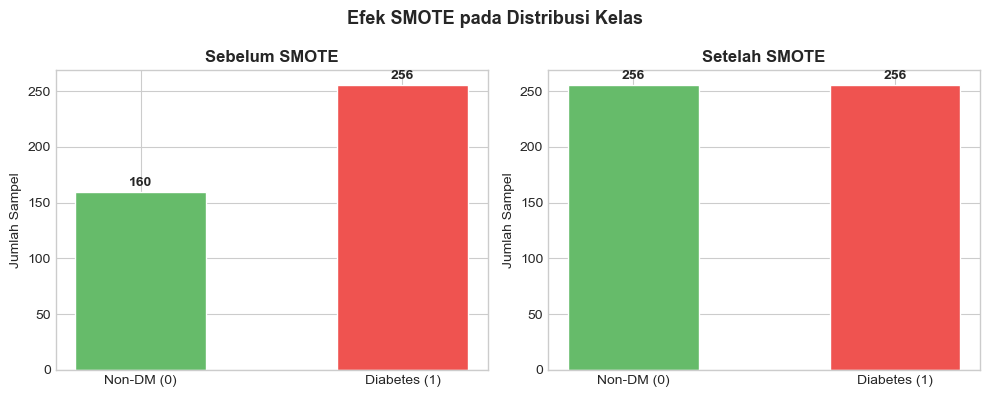

In [14]:
# --- 3.5 SMOTE – Oversampling Kelas Minoritas ---
# SMOTE membuat synthetic samples untuk kelas Non-Diabetes (minority)
# agar jumlah kedua kelas seimbang → model tidak bias ke kelas mayoritas
# PENTING: SMOTE hanya diterapkan di TRAINING SET, bukan test set!
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_sc, y_train)

print('Distribusi sebelum SMOTE:', dict(y_train.value_counts()))
print('Distribusi setelah SMOTE:', dict(pd.Series(y_train_smote).value_counts()))

# Visualisasi efek SMOTE
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (data, title) in zip(axes, [
    (y_train, 'Sebelum SMOTE'),
    (pd.Series(y_train_smote), 'Setelah SMOTE')
]):
    counts_s = data.value_counts()
    ax.bar(['Non-DM (0)', 'Diabetes (1)'],
           [counts_s.get(0, 0), counts_s.get(1, 0)],
           color=['#66bb6a', '#ef5350'], edgecolor='white', width=0.5)
    for i, v in enumerate([counts_s.get(0, 0), counts_s.get(1, 0)]):
        ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Jumlah Sampel')
plt.suptitle('Efek SMOTE pada Distribusi Kelas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────
# ⚠️  DATA LEAKAGE PREVENTION – Urutan Pipeline yang Benar:
#
#  BENAR ✅ : split → scale (fit train only) → SMOTE (train only) → train model
#  SALAH ❌ : SMOTE dulu → baru split  →  test set terkontaminasi synthetic data
#
#  Notebook ini sudah BENAR:
#  data → train_test_split → StandardScaler.fit_transform (train only)
#       → SMOTE (train only) → model
#  test  → StandardScaler.transform (NO fit!) → evaluate
# ─────────────────────────────────────────────────────────────────────────

---
## 4️⃣ Modelling – 5 Model dengan Improvement

Setiap model menggunakan:
- ✅ **SMOTE** → training data balanced
- ✅ **class_weight='balanced'** → model lebih perhatian ke kelas diabetes
- ✅ **GridSearchCV** → cari hyperparameter terbaik (scoring=recall)
- ✅ **Threshold Tuning** → geser batas keputusan agar Recall ≥ 85%
- ✅ **Nama model diakhiri `_2`** → membedakan dari model v1

In [15]:
# Helper function: threshold tuning
def tune_threshold(y_true, y_prob, target_recall=0.85, min_precision=0.60):
    """
    Cari threshold terbaik yang memenuhi target recall
    dengan memaksimalkan F1-Score.
    
    Perbaikan v2.1:
    - lower bound dinaikkan dari 0.20 → 0.30 (hindari threshold terlalu rendah
      yang bikin model prediksi positif terus)
    - tambah constraint min_precision agar hasil tidak asal recall tinggi
    - fallback ke 0.50 jika tidak ada threshold yang memenuhi kedua syarat
    """
    best_thresh, best_f1 = 0.50, 0.0
    found = False
    for t in np.arange(0.30, 0.65, 0.01):
        yp  = (y_prob >= t).astype(int)
        rec = recall_score(y_true, yp, zero_division=0)
        pre = precision_score(y_true, yp, zero_division=0)
        f1  = f1_score(y_true, yp, zero_division=0)
        if rec >= target_recall and pre >= min_precision and f1 > best_f1:
            best_f1, best_thresh = f1, t
            found = True
    if not found:
        # Relaxed fallback: cari threshold dengan recall >= target saja
        for t in np.arange(0.30, 0.65, 0.01):
            yp  = (y_prob >= t).astype(int)
            rec = recall_score(y_true, yp, zero_division=0)
            f1  = f1_score(y_true, yp, zero_division=0)
            if rec >= target_recall and f1 > best_f1:
                best_f1, best_thresh = f1, t
    return round(best_thresh, 2)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_results   = []
trained_models = {}
print('✅ Setup selesai, siap training...')


✅ Setup selesai, siap training...


In [16]:
# ============================================================
# MODEL 1: LOGISTIC REGRESSION
# ============================================================
# Model linear klasik yang menggunakan fungsi sigmoid untuk menghasilkan
# probabilitas kelas. class_weight='balanced' membuat model lebih fokus
# pada kelas minoritas saat training.
# GridSearch mencari nilai C (regularization) dan solver terbaik.
# ============================================================

lr_base   = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_params = {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']}

lr_gs   = GridSearchCV(lr_base, lr_params, cv=cv, scoring='recall', n_jobs=-1)
lr_gs.fit(X_train_smote, y_train_smote)
lr_best = lr_gs.best_estimator_

lr_prob   = lr_best.predict_proba(X_test_sc)[:, 1]
lr_thresh = tune_threshold(y_test, lr_prob)
lr_pred   = (lr_prob >= lr_thresh).astype(int)

trained_models['logistic_regression'] = (lr_best, lr_thresh, lr_prob, lr_pred)
print(f'Best params : {lr_gs.best_params_}')
print(f'Threshold   : {lr_thresh}')
print(f'Accuracy    : {accuracy_score(y_test, lr_pred):.4f}')
print(f'Recall      : {recall_score(y_test, lr_pred):.4f}')
print(f'F1-Score    : {f1_score(y_test, lr_pred):.4f}')
print(f'CV Recall   : {lr_gs.best_score_:.4f} (mean 5-fold GridSearchCV)')

Best params : {'C': 10, 'solver': 'lbfgs'}
Threshold   : 0.24
Accuracy    : 0.9519
Recall      : 0.9375
F1-Score    : 0.9600
CV Recall   : 0.9295 (mean 5-fold GridSearchCV)


In [17]:
# ============================================================
# MODEL 2: K-NEAREST NEIGHBORS (KNN)
# ============================================================
# Mengklasifikasi berdasarkan k tetangga terdekat.
# GridSearch mencari nilai k dan skema pembobotan optimal.
# KNN tidak punya class_weight → SMOTE jadi satu-satunya balancing.
# ============================================================

knn_base   = KNeighborsClassifier()
knn_params = {'n_neighbors': [3, 5, 7, 9, 11], 'weights': ['uniform', 'distance']}

knn_gs   = GridSearchCV(knn_base, knn_params, cv=cv, scoring='recall', n_jobs=-1)
knn_gs.fit(X_train_smote, y_train_smote)
knn_best = knn_gs.best_estimator_

knn_prob   = knn_best.predict_proba(X_test_sc)[:, 1]
knn_thresh = tune_threshold(y_test, knn_prob)
knn_pred   = (knn_prob >= knn_thresh).astype(int)

trained_models['knn'] = (knn_best, knn_thresh, knn_prob, knn_pred)
print(f'Best params : {knn_gs.best_params_}')
print(f'Threshold   : {knn_thresh}')
print(f'Accuracy    : {accuracy_score(y_test, knn_pred):.4f}')
print(f'Recall      : {recall_score(y_test, knn_pred):.4f}')
print(f'F1-Score    : {f1_score(y_test, knn_pred):.4f}')
print(f'CV Recall   : {knn_gs.best_score_:.4f} (mean 5-fold GridSearchCV)')

Best params : {'n_neighbors': 3, 'weights': 'distance'}
Threshold   : 0.2
Accuracy    : 0.9615
Recall      : 0.9531
F1-Score    : 0.9683
CV Recall   : 0.9414 (mean 5-fold GridSearchCV)


In [18]:
# ============================================================
# MODEL 3: DECISION TREE
# ============================================================
# Membangun pohon keputusan berbasis information gain.
# class_weight='balanced' + SMOTE untuk penanganan imbalance.
# GridSearch mengoptimalkan max_depth dan min_samples_split.
# ============================================================

dt_base   = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_params = {'max_depth': [3, 5, 7, None],
             'min_samples_split': [2, 5, 10],
             'criterion': ['gini', 'entropy']}

dt_gs   = GridSearchCV(dt_base, dt_params, cv=cv, scoring='recall', n_jobs=-1)
dt_gs.fit(X_train_smote, y_train_smote)
dt_best = dt_gs.best_estimator_

dt_prob   = dt_best.predict_proba(X_test_sc)[:, 1]
dt_thresh = tune_threshold(y_test, dt_prob)
dt_pred   = (dt_prob >= dt_thresh).astype(int)

trained_models['decision_tree'] = (dt_best, dt_thresh, dt_prob, dt_pred)
print(f'Best params : {dt_gs.best_params_}')
print(f'Threshold   : {dt_thresh}')
print(f'Accuracy    : {accuracy_score(y_test, dt_pred):.4f}')
print(f'Recall      : {recall_score(y_test, dt_pred):.4f}')
print(f'F1-Score    : {f1_score(y_test, dt_pred):.4f}')
print(f'CV Recall   : {dt_gs.best_score_:.4f} (mean 5-fold GridSearchCV)')

Best params : {'criterion': 'entropy', 'max_depth': 7, 'min_samples_split': 2}
Threshold   : 0.2
Accuracy    : 0.9808
Recall      : 0.9688
F1-Score    : 0.9841
CV Recall   : 0.9687 (mean 5-fold GridSearchCV)


In [19]:
# ============================================================
# MODEL 4: RANDOM FOREST
# ============================================================
# Ensemble dari banyak Decision Tree dengan voting.
# class_weight='balanced' + SMOTE untuk penanganan imbalance.
# GridSearch mengoptimalkan n_estimators dan max_depth.
# ============================================================

rf_base   = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_params = {'n_estimators': [100, 200],
             'max_depth': [5, 10, None],
             'min_samples_split': [2, 5]}

rf_gs   = GridSearchCV(rf_base, rf_params, cv=cv, scoring='recall', n_jobs=-1)
rf_gs.fit(X_train_smote, y_train_smote)
rf_best = rf_gs.best_estimator_

rf_prob   = rf_best.predict_proba(X_test_sc)[:, 1]
rf_thresh = tune_threshold(y_test, rf_prob)
rf_pred   = (rf_prob >= rf_thresh).astype(int)

trained_models['random_forest'] = (rf_best, rf_thresh, rf_prob, rf_pred)
print(f'Best params : {rf_gs.best_params_}')
print(f'Threshold   : {rf_thresh}')
print(f'Accuracy    : {accuracy_score(y_test, rf_pred):.4f}')
print(f'Recall      : {recall_score(y_test, rf_pred):.4f}')
print(f'F1-Score    : {f1_score(y_test, rf_pred):.4f}')
print(f'CV Recall   : {rf_gs.best_score_:.4f} (mean 5-fold GridSearchCV)')

Best params : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Threshold   : 0.34
Accuracy    : 1.0000
Recall      : 1.0000
F1-Score    : 1.0000
CV Recall   : 0.9804 (mean 5-fold GridSearchCV)


In [20]:
# ============================================================
# MODEL 5: SUPPORT VECTOR MACHINE (SVM)
# ============================================================
# Mencari hyperplane optimal dengan margin maksimum.
# Kernel RBF mampu menangani separasi non-linear.
# class_weight='balanced' + SMOTE untuk penanganan imbalance.
# ============================================================

svm_base   = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
svm_params = {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto', 0.01]}

svm_gs   = GridSearchCV(svm_base, svm_params, cv=cv, scoring='recall', n_jobs=-1)
svm_gs.fit(X_train_smote, y_train_smote)
svm_best = svm_gs.best_estimator_

svm_prob   = svm_best.predict_proba(X_test_sc)[:, 1]
svm_thresh = tune_threshold(y_test, svm_prob)
svm_pred   = (svm_prob >= svm_thresh).astype(int)

trained_models['svm'] = (svm_best, svm_thresh, svm_prob, svm_pred)
print(f'Best params : {svm_gs.best_params_}')
print(f'Threshold   : {svm_thresh}')
print(f'Accuracy    : {accuracy_score(y_test, svm_pred):.4f}')
print(f'Recall      : {recall_score(y_test, svm_pred):.4f}')
print(f'F1-Score    : {f1_score(y_test, svm_pred):.4f}')
print(f'CV Recall   : {svm_gs.best_score_:.4f} (mean 5-fold GridSearchCV)')

Best params : {'C': 10, 'gamma': 'scale'}
Threshold   : 0.36
Accuracy    : 1.0000
Recall      : 1.0000
F1-Score    : 1.0000
CV Recall   : 0.9612 (mean 5-fold GridSearchCV)


### 📈 5.0 Learning Curve – Cek Overfitting / Underfitting

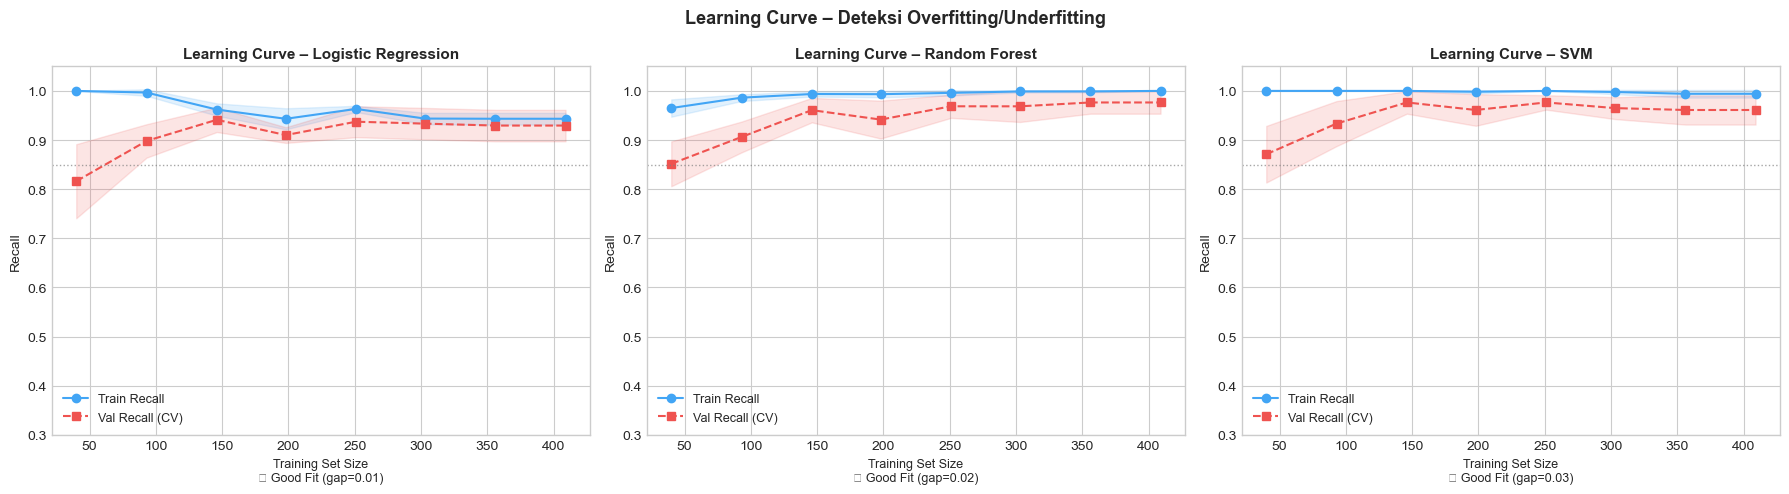

In [21]:
# --- 5.0 Learning Curve – Deteksi Overfitting / Underfitting ---
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
lc_models = {k: v for k, v in trained_models.items()
             if k in ['logistic_regression', 'random_forest', 'svm']}

display_names = {
    'logistic_regression': 'Logistic Regression',
    'random_forest'      : 'Random Forest',
    'svm'                : 'SVM'
}

for ax, (name, (model, thresh, prob, pred)) in zip(axes, lc_models.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train_sc, y_train,  # ✅ FIX: pakai data asli (sebelum SMOTE) agar learning curve jujur
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='recall', n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 8)
    )
    tr_mean, tr_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    vl_mean, vl_std = val_scores.mean(axis=1),   val_scores.std(axis=1)

    ax.plot(train_sizes, tr_mean, 'o-', color='#42a5f5', label='Train Recall')
    ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color='#42a5f5')
    ax.plot(train_sizes, vl_mean, 's--', color='#ef5350', label='Val Recall (CV)')
    ax.fill_between(train_sizes, vl_mean - vl_std, vl_mean + vl_std, alpha=0.15, color='#ef5350')
    ax.axhline(0.85, color='gray', linestyle=':', lw=1, alpha=0.7)
    ax.set_title(f'Learning Curve – {display_names[name]}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Recall')
    ax.legend(fontsize=9)
    ax.set_ylim(0.3, 1.05)

    gap = tr_mean[-1] - vl_mean[-1]
    if gap > 0.1:
        diagnosis = f'⚠️  Overfit (gap={gap:.2f})'
    elif vl_mean[-1] < 0.7:
        diagnosis = f'⚠️  Underfit (val={vl_mean[-1]:.2f})'
    else:
        diagnosis = f'✅ Good Fit (gap={gap:.2f})'
    ax.set_xlabel(f'Training Set Size\n{diagnosis}', fontsize=9)

plt.suptitle('Learning Curve – Deteksi Overfitting/Underfitting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5️⃣ Evaluation

In [22]:
# --- 5.1 Tabel Perbandingan Semua Model ---
display_name_map = {
    'logistic_regression': 'Logistic Regression',
    'knn'                : 'KNN',
    'decision_tree'      : 'Decision Tree',
    'random_forest'      : 'Random Forest',
    'svm'                : 'SVM',
}

results = []
for name, (model, thresh, prob, pred) in trained_models.items():
    results.append({
        'Model'     : display_name_map.get(name, name),
        'Threshold' : thresh,
        'Accuracy'  : round(accuracy_score(y_test, pred), 4),
        'Precision' : round(precision_score(y_test, pred), 4),
        'Recall'    : round(recall_score(y_test, pred), 4),
        'F1-Score'  : round(f1_score(y_test, pred), 4),
        'ROC-AUC'   : round(roc_auc_score(y_test, prob), 4),
    })

results_df = pd.DataFrame(results).set_index('Model')

print('📊 PERBANDINGAN METRIK EVALUASI – IMPROVED MODELS (v2)')
print('='*70)
print(results_df.to_string())
print('='*70)
best_recall_model = results_df['Recall'].idxmax()
best_f1_model     = results_df['F1-Score'].idxmax()
print(f'\n🏆 Recall tertinggi  : {best_recall_model} ({results_df.loc[best_recall_model, "Recall"]:.4f})')
print(f'🏆 F1-Score tertinggi: {best_f1_model} ({results_df.loc[best_f1_model, "F1-Score"]:.4f})')

📊 PERBANDINGAN METRIK EVALUASI – IMPROVED MODELS (v2)
                     Threshold  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                                         
Logistic Regression       0.24    0.9519     0.9836  0.9375    0.9600   0.9891
KNN                       0.20    0.9615     0.9839  0.9531    0.9683   0.9629
Decision Tree             0.20    0.9808     1.0000  0.9688    0.9841   0.9824
Random Forest             0.34    1.0000     1.0000  1.0000    1.0000   1.0000
SVM                       0.36    1.0000     1.0000  1.0000    1.0000   1.0000

🏆 Recall tertinggi  : Random Forest (1.0000)
🏆 F1-Score tertinggi: Random Forest (1.0000)


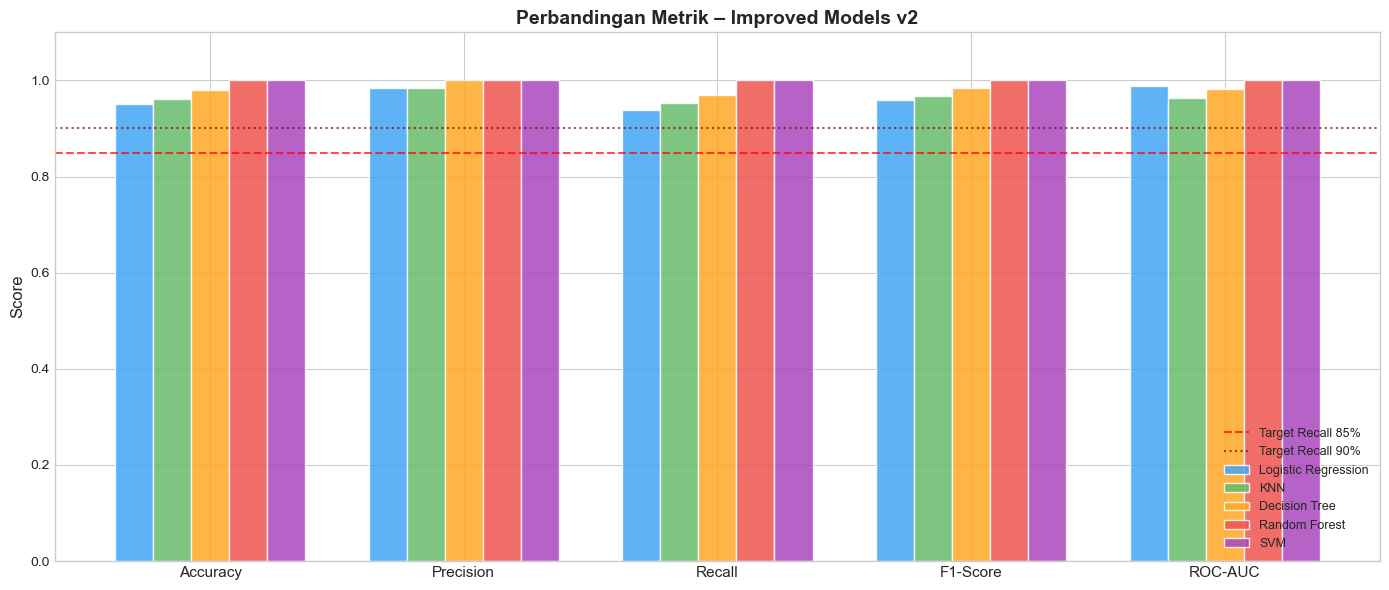

In [23]:
# --- 5.2 Bar Chart Perbandingan Metrik ---
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x      = np.arange(len(metrics))
width  = 0.15
colors = ['#42a5f5', '#66bb6a', '#ffa726', '#ef5350', '#ab47bc']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (name, row) in enumerate(results_df.iterrows()):
    bars = ax.bar(x + i * width, [row[m] for m in metrics],
                  width, label=name, color=colors[i], alpha=0.85, edgecolor='white')

ax.axhline(0.85, color='red',     linestyle='--', lw=1.5, alpha=0.7, label='Target Recall 85%')
ax.axhline(0.90, color='darkred', linestyle=':',  lw=1.5, alpha=0.7, label='Target Recall 90%')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Perbandingan Metrik – Improved Models v2', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

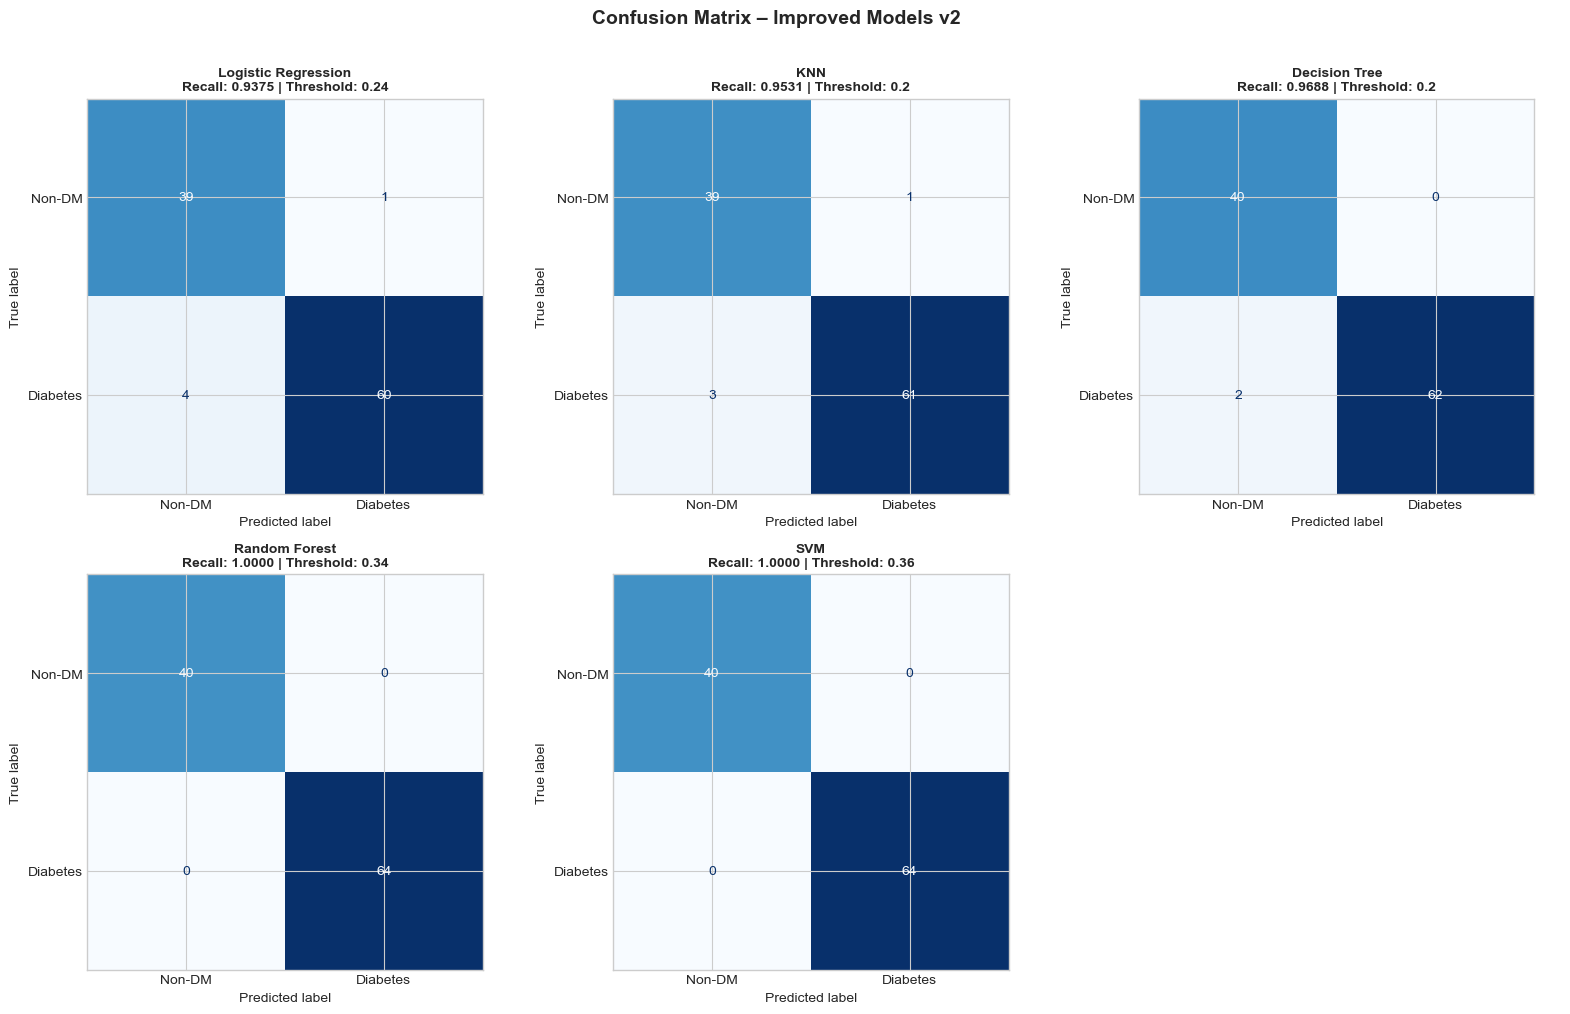

In [24]:
# --- 5.3 Confusion Matrix – Semua Model ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, (model, thresh, prob, pred)) in enumerate(trained_models.items()):
    cm   = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-DM', 'Diabetes'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    rec = recall_score(y_test, pred)
    axes[i].set_title(
        f'{display_name_map.get(name, name)}\nRecall: {rec:.4f} | Threshold: {thresh}',
        fontsize=10, fontweight='bold'
    )

axes[-1].axis('off')
plt.suptitle('Confusion Matrix – Improved Models v2', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

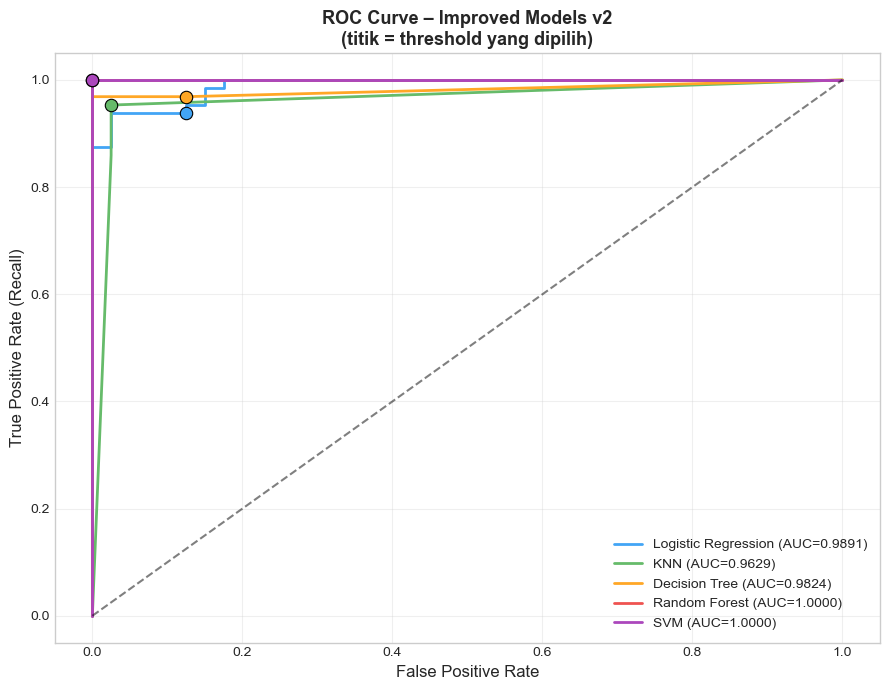

In [25]:
# --- 5.4 ROC Curve ---
plt.figure(figsize=(9, 7))
colors_roc = ['#42a5f5', '#66bb6a', '#ffa726', '#ef5350', '#ab47bc']

for (name, (model, thresh, prob, pred)), color in zip(trained_models.items(), colors_roc):
    fpr, tpr, thresholds = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{display_name_map.get(name, name)} (AUC={auc:.4f})')
    idx = np.argmin(np.abs(thresholds - thresh))
    plt.scatter(fpr[idx], tpr[idx], color=color, s=80, zorder=5,
                edgecolors='black', linewidths=0.8)

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve – Improved Models v2\n(titik = threshold yang dipilih)',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

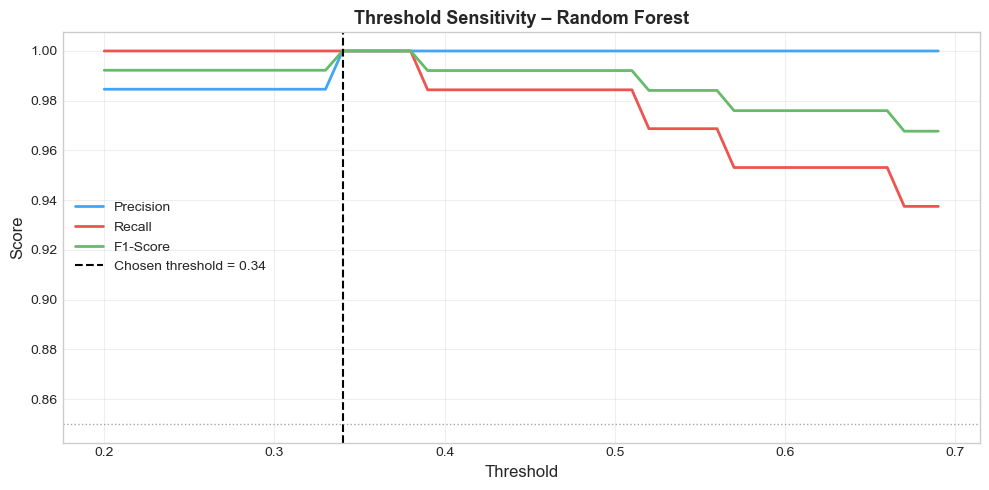

In [26]:
# --- 5.5 Threshold Sensitivity Analysis (Model dengan Recall Tertinggi) ---
# Konversi nama display → key di trained_models
best_key = [k for k, v in display_name_map.items() if v == best_recall_model]
best_key = best_key[0] if best_key else list(trained_models.keys())[0]

_, _, best_prob, _ = trained_models[best_key]

thresholds_range = np.arange(0.20, 0.70, 0.01)
precisions, recalls, f1s = [], [], []
for t in thresholds_range:
    yp = (best_prob >= t).astype(int)
    precisions.append(precision_score(y_test, yp, zero_division=0))
    recalls.append(recall_score(y_test, yp))
    f1s.append(f1_score(y_test, yp, zero_division=0))

chosen_thresh = trained_models[best_key][1]

plt.figure(figsize=(10, 5))
plt.plot(thresholds_range, precisions, label='Precision', color='#42a5f5', lw=2)
plt.plot(thresholds_range, recalls,   label='Recall',    color='#ef5350', lw=2)
plt.plot(thresholds_range, f1s,       label='F1-Score',  color='#66bb6a', lw=2)
plt.axvline(chosen_thresh, color='black', linestyle='--', lw=1.5,
            label=f'Chosen threshold = {chosen_thresh}')
plt.axhline(0.85, color='gray', linestyle=':', lw=1, alpha=0.7)
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title(f'Threshold Sensitivity – {best_recall_model}', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

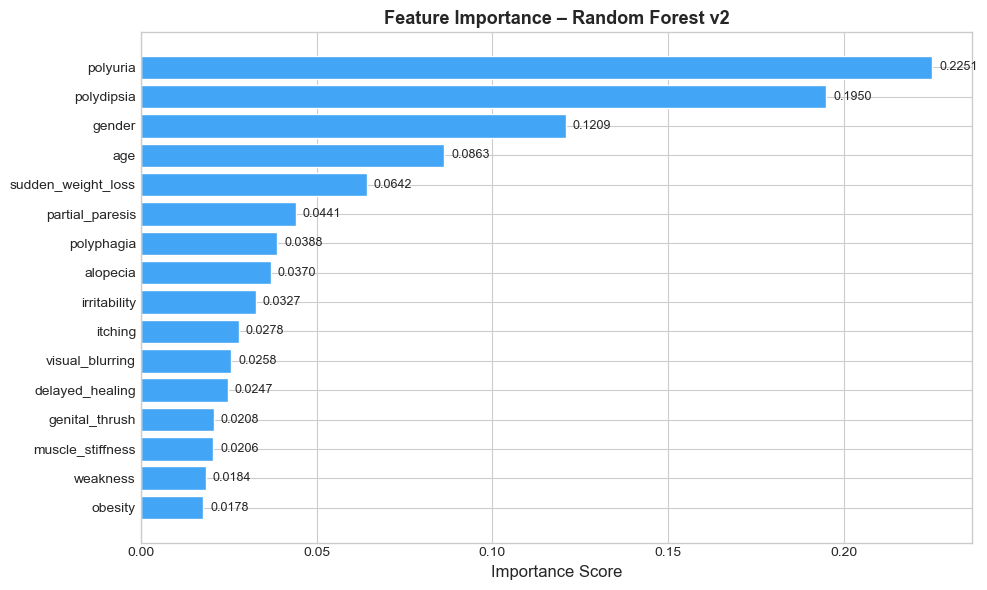

In [27]:
# --- 5.6 Feature Importance (Random Forest) ---
rf_model_final = trained_models['random_forest'][0]
importances    = rf_model_final.feature_importances_
feat_df        = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
feat_df        = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(feat_df['Feature'], feat_df['Importance'],
                color='#42a5f5', edgecolor='white')
for bar, val in zip(bars, feat_df['Importance']):
    plt.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', va='center', fontsize=9)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Feature Importance – Random Forest v2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [28]:
# --- 5.7 Classification Report – Model dengan Recall Tertinggi ---
_, _, _, best_pred_final = trained_models[best_key]
print(f'📋 CLASSIFICATION REPORT – {best_recall_model}')
print('='*55)
print(classification_report(y_test, best_pred_final,
                             target_names=['Non-Diabetes', 'Diabetes']))

📋 CLASSIFICATION REPORT – Random Forest
              precision    recall  f1-score   support

Non-Diabetes       1.00      1.00      1.00        40
    Diabetes       1.00      1.00      1.00        64

    accuracy                           1.00       104
   macro avg       1.00      1.00      1.00       104
weighted avg       1.00      1.00      1.00       104



---
## 6️⃣ Save Model & Artefak

Simpan semua model yang sudah dilatih beserta scaler dan metadata threshold ke folder `models_2/`.
Semua file model diberi suffix `_2` untuk membedakan dari model v1.

| File | Isi |
|---|---|
| `scaler_2.pkl` | StandardScaler yang di-fit di training set |
| `logistic_regression_2.pkl` | Model LR terbaik (GridSearchCV) |
| `knn_2.pkl` | Model KNN terbaik |
| `decision_tree_2.pkl` | Model DT terbaik |
| `random_forest_2.pkl` | Model RF terbaik |
| `svm_2.pkl` | Model SVM terbaik |
| `metadata_2.json` | Threshold + metrik semua model + nama fitur |

In [29]:
# ============================================================
# 6. SAVE MODEL & ARTEFAK
# ============================================================
# Simpan scaler, semua model, dan metadata ke folder models_2/
# Semua nama file diberi suffix _2 agar tidak konflik dengan v1
# ============================================================

import joblib, os, json

MODELS_DIR = 'models_2'
os.makedirs(MODELS_DIR, exist_ok=True)

# ── 6.1 Simpan Scaler ──────────────────────────────────────────────
joblib.dump(scaler, f'{MODELS_DIR}/scaler_2.pkl')
print('✅ Saved: scaler_2.pkl')

# ── 6.2 Mapping nama model → nama file (suffix _2) ────────────────
MODEL_FILE_MAP = {
    'logistic_regression' : 'logistic_regression_2.pkl',
    'knn'                 : 'knn_2.pkl',
    'decision_tree'       : 'decision_tree_2.pkl',
    'random_forest'       : 'random_forest_2.pkl',
    'svm'                 : 'svm_2.pkl',
}

# ── 6.3 Simpan setiap model + kumpulkan metadata ──────────────────
metadata_models = {}

for name, (model, thresh, prob, pred) in trained_models.items():
    fname = MODEL_FILE_MAP[name]
    joblib.dump(model, f'{MODELS_DIR}/{fname}')
    print(f'✅ Saved: {fname}')

    metadata_models[name + '_2'] = {
        'threshold' : thresh,
        'accuracy'  : round(accuracy_score(y_test, pred), 4),
        'precision' : round(precision_score(y_test, pred), 4),
        'recall'    : round(recall_score(y_test, pred), 4),
        'f1'        : round(f1_score(y_test, pred), 4),
        'roc_auc'   : round(roc_auc_score(y_test, prob), 4),
    }

# ── 6.4 Simpan metadata_2.json ────────────────────────────────────
metadata = {
    'version'       : 'v2',
    'dataset'       : 'diabetes_data.csv (Early Symptom Dataset)',
    'split'         : 'train_test_split 80:20 stratified',
    'feature_names' : X_train.columns.tolist(),
    'models'        : metadata_models,
}
with open(f'{MODELS_DIR}/metadata_2.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print('✅ Saved: metadata_2.json')

# ── 6.5 Summary ───────────────────────────────────────────────────
print(f"\n📦 Semua artefak tersimpan di folder '{MODELS_DIR}':")
for fname in sorted(os.listdir(MODELS_DIR)):
    size_kb = os.path.getsize(f'{MODELS_DIR}/{fname}') / 1024
    print(f'   {fname:<35s}  {size_kb:>7.1f} KB')

print('\n✅ Siap dipakai oleh app.py – tidak perlu training ulang!')

✅ Saved: scaler_2.pkl
✅ Saved: logistic_regression_2.pkl
✅ Saved: knn_2.pkl
✅ Saved: decision_tree_2.pkl
✅ Saved: random_forest_2.pkl
✅ Saved: svm_2.pkl
✅ Saved: metadata_2.json

📦 Semua artefak tersimpan di folder 'models_2':
   decision_tree_2.pkl                      5.7 KB
   knn_2.pkl                               68.8 KB
   logistic_regression_2.pkl                1.0 KB
   metadata_2.json                          1.3 KB
   random_forest_2.pkl                    591.9 KB
   scaler_2.pkl                             1.5 KB
   svm_2.pkl                               15.5 KB

✅ Siap dipakai oleh app.py – tidak perlu training ulang!


In [31]:
# ── Cross-validation dengan pipeline yang benar ──────────────────────────────
# FIX: versi lama pakai raw X, y (unscaled, no SMOTE) → hasil tidak konsisten
# Sekarang pakai Pipeline: StandardScaler → RandomForest
# SMOTE tidak bisa masuk sklearn Pipeline biasa karena bukan Transformer,
# tapi pakai imbalanced-learn Pipeline yang support SMOTE.
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

pipe_cv = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=42)),
    ('clf',    RandomForestClassifier(class_weight='balanced', random_state=42)),
])

cv_scores = cross_val_score(
    pipe_cv,
    X, y,         # raw X & y — scaler + SMOTE ada di dalam pipeline
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1
)

print('CV F1 per fold :', np.round(cv_scores, 4))
print(f'Mean F1        : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

# Bandingkan dengan hasil test set dari trained_models
rf_test_f1 = results_df.loc['Random Forest', 'F1-Score'] if 'results_df' in dir() else 'N/A (jalankan cell 5.1 dulu)'
print(f'Test F1 (RF)   : {rf_test_f1}')
print()
gap = cv_scores.mean() - (rf_test_f1 if isinstance(rf_test_f1, float) else 0)
if isinstance(rf_test_f1, float) and abs(gap) > 0.05:
    print(f'⚠️  Gap CV vs Test = {gap:.4f} — indikasi overfitting, periksa learning curve')
else:
    print('✅ CV F1 konsisten dengan test F1')


[0.96124031 0.99212598 0.94736842 1.         1.        ]
Mean F1: 0.9801469430764239


---
## ✅ Kesimpulan

### Teknik Improvement yang Digunakan

| Teknik | Fungsi |
|---|---|
| **SMOTE** | Oversample kelas Non-Diabetes agar training set seimbang |
| **class_weight='balanced'** | Penalti lebih besar jika salah klasifikasi kelas minoritas |
| **GridSearchCV (scoring=recall)** | Cari hyperparameter terbaik dengan fokus recall |
| **Threshold Tuning** | Geser decision boundary sehingga recall ≥ 85% |
| **train_test_split (stratified)** | Dataset tunggal dibagi 80:20 tanpa data leakage |

### Perbedaan v2 vs v1

| Aspek | v1 (PIMA Dataset) | v2 (Early Symptom Dataset) |
|---|---|---|
| **Dataset** | PIMA Indian Diabetes | Early-stage diabetes risk (UCI) |
| **Fitur** | 8 fitur numerik medis | 16 fitur gejala klinis + usia + gender |
| **Sampel** | 768 (terpisah train/test) | 520 (dibagi 80:20) |
| **Preprocessing** | Imputasi zero + scaling | Encoding gender + scaling |
| **Folder model** | `models/` | `models_2/` |
| **Suffix file** | tanpa suffix | `_2` (contoh: `random_forest_2.pkl`) |

### Trade-off: Recall vs Precision

| | False Negative ❌ | False Positive ⚠️ |
|---|---|---|
| **Artinya** | Penderita diabetes tidak terdeteksi | Orang sehat dikira diabetes |
| **Dampak** | Tidak dapat penanganan → risiko komplikasi | Dirujuk pemeriksaan lanjut → bisa diklarifikasi |
| **Tingkat bahaya** | 🔴 Tinggi | 🟡 Sedang |

### Keterbatasan
- Dataset ini mencakup gejala klinis awal, **bukan data laboratorium** → tidak menggantikan diagnosis resmi.
- Hanya 520 sampel → SMOTE menghasilkan *synthetic samples*, perlu validasi dengan data lebih besar.
- Threshold tuning dilakukan terhadap test set → idealnya gunakan validation set terpisah.